In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [46]:
df = pd.read_csv("car data.csv")

In [47]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [49]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [50]:
df.duplicated().sum()

np.int64(2)

In [51]:
df.drop_duplicates(inplace=True)

In [52]:
df.duplicated().sum()

np.int64(0)

In [53]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [54]:
from sklearn.preprocessing import LabelEncoder

In [55]:
df_label = LabelEncoder()
df['Fuel_Type'] = df_label.fit_transform(df['Fuel_Type'])

In [56]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,2,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,1,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,2,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,2,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,1,Dealer,Manual,0


In [57]:
df['Fuel_Type'].value_counts()

Fuel_Type
2    239
1     58
0      2
Name: count, dtype: int64

In [58]:
df['Selling_type'] = df_label.fit_transform(df['Selling_type'])

In [59]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,2,0,Manual,0
1,sx4,2013,4.75,9.54,43000,1,0,Manual,0
2,ciaz,2017,7.25,9.85,6900,2,0,Manual,0
3,wagon r,2011,2.85,4.15,5200,2,0,Manual,0
4,swift,2014,4.60,6.87,42450,1,0,Manual,0


In [60]:
df['Transmission'] = df_label.fit_transform(df['Transmission'])

In [61]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,2,0,1,0
1,sx4,2013,4.75,9.54,43000,1,0,1,0
2,ciaz,2017,7.25,9.85,6900,2,0,1,0
3,wagon r,2011,2.85,4.15,5200,2,0,1,0
4,swift,2014,4.60,6.87,42450,1,0,1,0


In [62]:
df['Current_year'] = 2026

In [64]:
df['Car_Age'] = df['Current_year'] - df['Year']

In [65]:
df.drop(['Car_Name','Year','Current_year'],
       axis = 1,
       inplace = True)

In [66]:
x = df.drop('Selling_Price',axis=1)

In [67]:
y = df['Selling_Price']

In [71]:
X_train,X_test,Y_train,Y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42
)

In [72]:
linear_model = LinearRegression()

In [73]:
linear_model.fit(X_train,Y_train)

LinearRegression()

In [74]:
linear_prediction = linear_model.predict(X_test)

In [75]:
mean_absolute_error(Y_test,linear_prediction)

1.540811954969353

In [76]:
mean_squared_error(Y_test,linear_prediction)

6.675444100492253

In [77]:
r2_score(Y_test,linear_prediction)

0.7409934356413542

In [78]:
random_model = RandomForestRegressor()

In [79]:
random_model.fit(X_train,Y_train)

RandomForestRegressor()

In [80]:
random_prediction = random_model.predict(X_test)

In [82]:
r2_score(Y_test,random_prediction)

0.5601801860356053

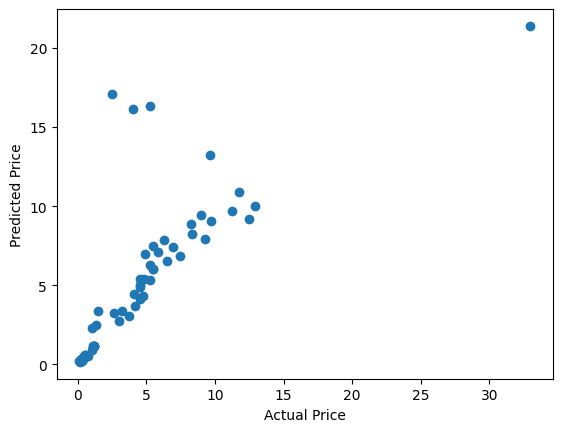

In [86]:
plt.scatter(Y_test,random_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

In [93]:
new_car = x.iloc[0:1]

In [94]:
predicted_price = random_model.predict(new_car)

In [95]:
predicted_price

array([3.7785])